# Workflow AI Agent Structure

This notebook walks through a complete workflow-oriented AI agent design from dataset generation, enrichment, and exploration to schema alignment and model evaluation.

## Imports and Configuration

Before running this notebook, create a `.env` file containing your API key:
```
OPENAI_API_KEY=YOUR_KEY
```
Ensure all required libraries are installed in your environment. This notebook assumes access to OpenAI’s SDK, pandas, and other standard scientific Python tools.

In [2]:
%pip install langchain langgraph langchain-openai openai tiktoken pandas numpy pydantic python-dotenv rich faker seaborn matplotlib pygraphviz pydot graphviz ipython jupyterlab


  Using cached pygraphviz-1.14.tar.gz (106 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build pygraphviz
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for pygraphviz (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [88 lines of output]
      C:\Users\AJ\AppData\Local\Temp\pip-build-env-zhajx0fr\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `project.license` as a TOML table is deprecated
      !!
      
              ********************************************************************************
              Please use a simple string containing a SPDX expression for `project.license`. You can also use `project.license-files`. (Both options available on setuptools>=77.0.0).
      
              By 2026-Feb-18, you need to update your project and remove deprecated calls
              or your builds will no longer be supported.
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              *************************************************

In [2]:
import logging

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger("MAS-Pipeline")

In [ ]:
from dotenv import load_dotenv
import os, json, re
import pandas as pd
import numpy as np
from pydantic import BaseModel, ValidationError, Field, confloat, constr
from IPython.display import Image, display


from typing import List, Optional, Literal, Dict, Any, Union
from rich import print as rprint

import random
from faker import Faker
from datetime import datetime, timedelta, date

from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

from langchain_openai import ChatOpenAI

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Set up consistent plotting style
sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

# Load env vars
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

MODEL_NAME = "gpt-4o-mini"
assert OPENAI_API_KEY, "Set OPENAI_API_KEY env var in .env"

llm = ChatOpenAI(
    api_key=OPENAI_API_KEY,
    model_name=MODEL_NAME,
    temperature=0,
    max_tokens=700
)

rprint(f"[bold green]OpenAI (LangChain) ready with model: {MODEL_NAME}[/bold green]")


OpenAI (LangChain) ready with model: gpt-4o-mini

## Generating and Enriching Synthetic Study Datasets

In this section, we create realistic synthetic datasets and enrich them with additional metadata.

These datasets are generated defining different persona patterns to ensure a more realistic final result.

We will be using them throughout the notebook to test the agent workflow.
To ensure dataset quality EDA, validation, and schema alignment will also be performed.


In [4]:
fake = Faker()
Faker.seed(42)
np.random.seed(42)
random.seed(42)


### DATA GENERATION FUNCTIONS ###

def generate_customers(n_customers: int = 100) -> pd.DataFrame:
    """
    Generate synthetic customer data with distinct risk profiles and personas.
    """
    customer_ids = [f"CUST-{1000+i}" for i in range(n_customers)]
    
    # Create different customer personas with varying risk levels
    personas = {
        "low_risk": {
            "prob": 0.5, 
            "countries": ["US", "UK", "DE", "PT"], 
            "kyc": ["enhanced", "basic"], 
            "balance_mult": 1.0
        },
        "medium_risk": {
            "prob": 0.3, 
            "countries": ["IN", "SG", "BR", "AE"], 
            "kyc": ["basic", "simplified"], 
            "balance_mult": 0.8
        },
        "high_risk": {
            "prob": 0.15, 
            "countries": ["NG", "RU", "IR", "PK"], 
            "kyc": ["simplified", "basic"], 
            "balance_mult": 0.5
        },
        "suspicious": {
            "prob": 0.05, 
            "countries": ["RU", "IR", "PK", "NG"], 
            "kyc": ["simplified"], 
            "balance_mult": 0.3
        }
    }
    
    # Assign personas to customers
    persona_assignments = []
    for persona, config in personas.items():
        count = int(n_customers * config["prob"])
        persona_assignments.extend([persona] * count)
    
    # Fill remaining slots with low_risk
    while len(persona_assignments) < n_customers:
        persona_assignments.append("low_risk")
    
    random.shuffle(persona_assignments)
    
    customers_data = []
    for i, persona in enumerate(persona_assignments):
        config = personas[persona]
        
        # Select country based on persona
        country = random.choice(config["countries"])
        kyc_level = random.choice(config["kyc"])
        
        # Generate balance based on persona and country
        base_mean = {"basic": 7, "simplified": 8, "enhanced": 9}[kyc_level]
        if country in ["US", "UK", "DE", "SG", "AE"]:
            base_mean += 0.3
        
        balance = np.random.lognormal(base_mean, 0.8) * config["balance_mult"]
        
        # Add some extreme cases for suspicious personas
        if persona == "suspicious" and random.random() < 0.4:
            balance *= random.uniform(10, 100)
        
        customers_data.append({
            "customer_id": customer_ids[i],
            "name": fake.name(),
            "dob": fake.date_of_birth(minimum_age=18, maximum_age=80),
            "country": country,
            "kyc_level": kyc_level,
            "account_open_date": fake.date_between(start_date="-5y", end_date="today"),
            "balance_usd": round(balance, 2),
            "risk_persona": persona
        })
    
    return pd.DataFrame(customers_data)


def generate_crypto_activity(customers: pd.DataFrame, n_wallets: int = 20) -> pd.DataFrame:
    """
    Generate synthetic cryptocurrency wallet activity data linked to customers.
    """
    # Define wallets: assets, balances, tx counts
    wallet_ids = [f"WALLET-{i:05d}" for i in range(n_wallets)]
    assets = ["BTC", "ETH", "XRP", "SOL", "ADA", "DOGE"]
    asset_probs = [0.5, 0.2, 0.05, 0.15, 0.05, 0.05]
    chosen_assets = np.random.choice(assets, p=asset_probs, size=n_wallets)
    balances = np.random.lognormal(mean=2, sigma=1.2, size=n_wallets)
    on_chain_tx_count = np.random.poisson(lam=balances * 2)
    crypto_customers = np.random.choice(customers["customer_id"], size=n_wallets, replace=False)

    data = {
        "wallet_id": wallet_ids,
        "customer_id": crypto_customers,
        "crypto_asset": chosen_assets,
        "wallet_address": [fake.sha256(raw_output=False)[:20] for _ in range(n_wallets)],
        "balance": np.round(balances, 4),
        "on_chain_tx_count": on_chain_tx_count,
    }
    return pd.DataFrame(data)

def generate_transactions(customers: pd.DataFrame, crypto_customers: pd.Series, n_trx: int = 5000) -> pd.DataFrame:
    """
    Generate synthetic transaction data with persona-based risk patterns.
    """
    transactions = []
    trx_id_counter = 100000
    
    # Define transaction patterns by persona
    persona_patterns = {
        "low_risk": {
            "types": ["deposit", "withdrawal", "transfer"],
            "type_probs": [0.5, 0.35, 0.15],
            "amount_params": {"deposit": (6.5, 0.5), "withdrawal": (6, 0.6), "transfer": (6.5, 0.7)},
            "frequency_range": (1, 2),
            "suspicious_desc_prob": 0.01,
            "extreme_amount_prob": 0.001
        },
        "medium_risk": {
            "types": ["deposit", "withdrawal", "transfer", "crypto_buy"],
            "type_probs": [0.4, 0.3, 0.2, 0.1],
            "amount_params": {"deposit": (7.5, 0.8), "withdrawal": (7, 0.8), "transfer": (7.5, 0.9), "crypto_buy": (8, 1.0)},
            "frequency_range": (2, 5),
            "suspicious_desc_prob": 0.08,
            "extreme_amount_prob": 0.02
        },
        "high_risk": {
            "types": ["deposit", "withdrawal", "transfer", "crypto_buy", "crypto_sell"],
            "type_probs": [0.25, 0.25, 0.25, 0.15, 0.1],
            "amount_params": {"deposit": (8.5, 1.1), "withdrawal": (8, 1.0), "transfer": (8.5, 1.2), "crypto_buy": (9, 1.3), "crypto_sell": (8.8, 1.2)},
            "frequency_range": (4, 10),
            "suspicious_desc_prob": 0.2,
            "extreme_amount_prob": 0.08
        },
        "suspicious": {
            "types": ["deposit", "withdrawal", "transfer", "crypto_buy", "crypto_sell"],
            "type_probs": [0.15, 0.15, 0.4, 0.2, 0.1],
            "amount_params": {"deposit": (9.5, 1.4), "withdrawal": (9, 1.3), "transfer": (10, 1.5), "crypto_buy": (10.5, 1.6), "crypto_sell": (10, 1.5)},
            "frequency_range": (8, 30),
            "suspicious_desc_prob": 0.5,
            "extreme_amount_prob": 0.25
        }
    }
    
    # Enhanced suspicious descriptions by type
    suspicious_descriptions = {
        "deposit": [
            "Urgent cash deposit from crypto friend", 
            "Gift payment refund split", 
            "Emergency transfer from offshore", 
            "Cash deposit for urgent exchange",
            "Refund for invoice split transaction"
        ],
        "withdrawal": [
            "Cash for urgent crypto gift", 
            "ATM withdrawal for exchange split", 
            "Urgent payment for offshore transfer",
            "Cash withdrawal for gift exchange",
            "Emergency cash for crypto friend"
        ],
        "transfer": [
            "Wire transfer to offshore entity", 
            "Urgent gift to crypto family", 
            "Transfer split for exchange", 
            "Business payment urgent cash",
            "Offshore wire for urgent gift",
            "Transfer to exchange for cash"
        ],
        "crypto_buy": [
            "Urgent crypto purchase for gift", 
            "Buy crypto for offshore friend", 
            "Exchange crypto urgent cash",
            "Crypto buy for gift split",
            "Urgent digital asset purchase"
        ],
        "crypto_sell": [
            "Urgent crypto liquidation gift", 
            "Sell crypto for cash friend", 
            "Crypto exchange urgent transfer",
            "Digital asset sale for gift",
            "Crypto liquidation urgent"
        ]
    }
    
    start_date = datetime.now() - timedelta(days=365)
    
    # Generate transactions for each customer based on their persona
    for _, customer in customers.iterrows():
        persona = customer.get('risk_persona', 'low_risk')
        pattern = persona_patterns[persona]
        
        # Determine number of transactions for this customer
        base_txn_count = int(n_trx / len(customers))
        if persona == "suspicious":
            txn_count = int(base_txn_count * random.uniform(3, 8))  # Suspicious customers are very active
        elif persona == "high_risk":
            txn_count = int(base_txn_count * random.uniform(2, 4))
        elif persona == "medium_risk":
            txn_count = int(base_txn_count * random.uniform(1, 2))
        else:
            txn_count = int(base_txn_count * random.uniform(0.3, 1))
        
        # Ensure some minimum activity for suspicious customers
        if persona == "suspicious":
            txn_count = max(txn_count, 15)
        elif persona == "high_risk":
            txn_count = max(txn_count, 8)
        
        # Generate transactions for this customer
        for _ in range(txn_count):
            # Select transaction type based on persona
            trx_type = np.random.choice(pattern["types"], p=pattern["type_probs"])
            
            # Skip crypto transactions for non-crypto customers
            if trx_type in ["crypto_buy", "crypto_sell"] and customer["customer_id"] not in crypto_customers:
                trx_type = "transfer"  # Fallback to transfer
            
            # Generate amount based on type and persona
            if trx_type in pattern["amount_params"]:
                mean, sigma = pattern["amount_params"][trx_type]
            else:
                mean, sigma = (7, 1.0)  # Default
            
            amount = np.random.lognormal(mean, sigma)
            
            # Add extreme amounts based on persona probability
            if random.random() < pattern["extreme_amount_prob"]:
                if persona == "suspicious":
                    amount *= random.uniform(10, 50)
                elif persona == "high_risk":
                    amount *= random.uniform(5, 15)
                elif persona == "medium_risk":
                    amount *= random.uniform(2, 8)
            
            # Generate timestamp with clustering for suspicious customers
            if persona == "suspicious" and random.random() < 0.4:
                # Create time clustering (structuring behavior)
                cluster_start = start_date + timedelta(days=random.randint(0, 300))
                timestamp = cluster_start + timedelta(
                    hours=random.randint(0, 72),  # Within 3 days
                    minutes=random.randint(0, 59)
                )
            elif persona in ["high_risk", "suspicious"] and random.random() < 0.2:
                # Some off-hours activity
                base_date = start_date + timedelta(days=random.randint(0, 365))
                timestamp = base_date.replace(
                    hour=random.choice([2, 3, 4, 22, 23, 0, 1]),  # Suspicious hours
                    minute=random.randint(0, 59)
                )
            else:
                timestamp = start_date + timedelta(
                    days=random.randint(0, 365),
                    hours=random.randint(8, 18),  # Business hours for normal customers
                    minutes=random.randint(0, 59)
                )
            
            # Generate description based on suspicion probability
            if random.random() < pattern["suspicious_desc_prob"]:
                description = random.choice(suspicious_descriptions.get(trx_type, ["Suspicious transaction"]))
            else:
                # Normal descriptions
                desc_map = {
                    "deposit": ["Salary payment", "Bank deposit", "Investment income", "Business revenue"],
                    "withdrawal": ["ATM withdrawal", "Online purchase", "Bill payment", "Rent payment"],
                    "transfer": ["Family transfer", "Business payment", "P2P transfer", "Investment transfer"],
                    "crypto_buy": ["Crypto purchase", "Digital asset investment", "Portfolio diversification"],
                    "crypto_sell": ["Crypto sale", "Digital asset liquidation", "Profit taking"]
                }
                description = random.choice(desc_map.get(trx_type, ["Standard transaction"]))
            
            # Handle receiver for transfers with cross-border potential
            receiver_id = None
            if trx_type == "transfer":
                if persona in ["suspicious", "high_risk"] and random.random() < 0.3:
                    # Cross-persona transfers (suspicious to suspicious, etc.)
                    same_persona_customers = customers[
                        (customers["risk_persona"] == persona) & 
                        (customers["customer_id"] != customer["customer_id"])
                    ]["customer_id"]
                    if len(same_persona_customers) > 0:
                        receiver_id = random.choice(same_persona_customers.tolist())
                    else:
                        possible_receivers = customers[customers["customer_id"] != customer["customer_id"]]["customer_id"]
                        if len(possible_receivers) > 0:
                            receiver_id = random.choice(possible_receivers.tolist())
                else:
                    possible_receivers = customers[customers["customer_id"] != customer["customer_id"]]["customer_id"]
                    if len(possible_receivers) > 0:
                        receiver_id = random.choice(possible_receivers.tolist())
            
            # Determine currency with some bias
            if trx_type in ["crypto_buy", "crypto_sell"]:
                if persona == "suspicious":
                    # Suspicious customers prefer certain crypto
                    currency = random.choice(["BTC", "ETH", "XRP", "ADA"])  # No privacy coins in schema
                else:
                    currency = random.choice(["BTC", "ETH", "XRP", "SOL", "ADA", "DOGE"])
            else:
                if customer["country"] in ["US"]:
                    currency = "USD"
                elif customer["country"] in ["DE"]:
                    currency = "EUR"
                elif customer["country"] in ["UK"]:
                    currency = "GBP"
                else:
                    # Some preference for USD in high-risk countries
                    if persona in ["high_risk", "suspicious"]:
                        currency = random.choice(["USD", "USD", "EUR"])  # USD bias
                    else:
                        currency = random.choice(["USD", "EUR", "GBP"])
            
            transactions.append({
                "trx_id": f"TX-{trx_id_counter}",
                "timestamp": timestamp,
                "customer_id": customer["customer_id"],
                "receiver_id": receiver_id,
                "currency": currency,
                "amount": round(amount, 2),
                "trx_type": trx_type,
                "description": description
            })
            
            trx_id_counter += 1
    
    # Shuffle and limit to requested number
    random.shuffle(transactions)
    return pd.DataFrame(transactions[:n_trx])

### DATA ENRICHMENT FUNCTIONS ###

def amount_z_score(df: pd.DataFrame, column: str = "amount") -> pd.DataFrame:
    """
    Calculate z-scores for the specified column in the DataFrame.
    """
    amt_mean = df[column].mean()
    amt_std = df[column].std(ddof=0) or 1.0
    df[f"{column}_z"] = (df[column] - amt_mean) / amt_std
    return df

def transaction_velocity(df: pd.DataFrame, time_window: int = 7) -> pd.DataFrame:
    """
    Calculate transaction velocity (number of transactions per time window) for each customer.
    This matches the exact logic of the inline implementation.
    """
    df = df.copy()
    df = df.sort_values(['customer_id','timestamp'])
    df['c_txn_7d'] = 0
    
    # Calculate rolling count of transactions within the time window
    for _, grp in df.groupby('customer_id'):
        idxs = grp.index.tolist()
        for _, idx in enumerate(idxs):
            d = grp.loc[idx, 'timestamp']
            n = grp[(grp['timestamp'] >= d - pd.Timedelta(days=time_window)) & 
                    (grp['timestamp'] <= d)].shape[0]
            df.loc[idx, 'c_txn_7d'] = n
    
    return df

def keyword_flag(df: pd.DataFrame, kw: re.Pattern = None) -> pd.DataFrame:
    """
    Flag transactions containing a specific keyword in the description.
    """
    if kw is None:
        kw = re.compile(r"\b(crypto|cash|gift|urgent|refund|invoice split|transfer split|exchange)\b", re.I) # Example keywords
    df['kw_flag'] = df['description'].fillna("").str.contains(kw).astype(int)
    return df

def multi_country_tx_flag(df: pd.DataFrame, customers: pd.DataFrame) -> pd.DataFrame:
    """
    Flag customers with transactions in multiple countries.
    """
    customers_country = customers[['customer_id', 'country']].rename(columns={'customer_id': 'receiver_id', 'country': 'receiver_country'})
    df = df.merge(customers_country, on='receiver_id', how='left')
    transfer_tx = df[df['trx_type'] == 'transfer']
    # Identify customers with multiple receiver countries
    multi_country = (
        transfer_tx.groupby('customer_id')['receiver_country']
                .nunique()
                .reset_index(name='unique_receiver_countries')
    )
    multi_country['multi_country_flag'] = (multi_country['unique_receiver_countries'] > 1).astype(int)
    df = df.merge(
        multi_country[['customer_id', 'multi_country_flag']],
        on='customer_id',
        how='left'
    )
    df['multi_country_flag'] = df['multi_country_flag'].fillna(0).astype(int)
    return df

def structuring_flag(df: pd.DataFrame, threshold: int = 7, amount_limit: float = 10000) -> pd.DataFrame:
    """
    Flag customers with more than threshold small transactions (< amount_limit) in a month.
    """
    df['month'] = df['timestamp'].dt.to_period('M')
    # Calculate monthly small transaction counts
    monthly_small_tx = (
        df[df['amount'] < amount_limit]
        .groupby(['customer_id', 'month'])
        .size()
    .reset_index(name='small_tx_count')
    )

    monthly_small_tx['structuring_flag'] = (monthly_small_tx['small_tx_count'] > threshold).astype(int)
    df = df.merge(
        monthly_small_tx[['customer_id', 'month', 'structuring_flag']],
        on=['customer_id', 'month'],
        how='left'
    ).drop(columns=["month"])
    df['structuring_flag'] = df['structuring_flag'].fillna(0).astype(int)
    return df

def many_types_trx_flag(df: pd.DataFrame, type_threshold: int = 4) -> pd.DataFrame:
    """
    Flag customers with transactions of many different types.
    """
    # Calculate unique transaction types per customer
    trx_types_per_customer = (
        df.groupby('customer_id')['trx_type']
        .nunique()
        .reset_index(name='unique_trx_types')
    )
    trx_types_per_customer['many_trx_types_flag'] = (trx_types_per_customer['unique_trx_types'] >= type_threshold).astype(int)
    df = df.merge(
        trx_types_per_customer[['customer_id', 'many_trx_types_flag']],
        on='customer_id',
        how='left'
    )
    df['many_trx_types_flag'] = df['many_trx_types_flag'].fillna(0).astype(int)
    return df

def crypto_activity_flag(df: pd.DataFrame) -> pd.DataFrame:
    """
    Flag customers with any cryptocurrency activity.
    """
    crypto_activity = (
        df.groupby('customer_id')['trx_type']
        .apply(lambda x: any(t in ['crypto_buy', 'crypto_sell'] for t in x))
        .reset_index(name='crypto_activity_flag')
    )
    crypto_activity['crypto_activity_flag'] = crypto_activity['crypto_activity_flag'].astype(int)
    df = df.merge(
        crypto_activity[['customer_id', 'crypto_activity_flag']],
        on='customer_id',
        how='left'
    )
    df['crypto_activity_flag'] = df['crypto_activity_flag'].fillna(0).astype(int)
    return df

def velocity_spike_flag(df: pd.DataFrame, threshold: float = 3.0) -> pd.DataFrame:
    """
    Flag transactions with high velocity z-scores.
    """
    # Calculate median transaction velocity per customer
    velocity_stats = (
        df.groupby('customer_id')['c_txn_7d']
        .median()
        .reset_index(name='median_txn_7d')
    )
    df = df.merge(velocity_stats, on='customer_id', how='left')
    # Flag transactions exceeding threshold times median velocity
    df['velocity_spike_flag'] = (df['c_txn_7d'] > threshold * df['median_txn_7d']).astype(int)
    df.drop(columns=['median_txn_7d'], inplace=True)
    return df

def enrich_customers_with_transaction_history(customers: pd.DataFrame, trx: pd.DataFrame) -> pd.DataFrame:
    """
    Enrich customer data with comprehensive transaction history features.
    Returns only the columns defined in EnrichedCustomer schema.
    """
    customers_enriched = customers.copy()
    
    # Aggregate transaction statistics per customer
    trx_stats = trx.groupby('customer_id').agg({
        'amount': ['count', 'sum', 'mean', 'max'],
        'timestamp': ['min', 'max'],
        'trx_type': 'nunique',
        'currency': 'nunique'
    }).round(2)
    
    # Flatten multi-level columns
    trx_stats.columns = [f"{col[0]}_{col[1]}" for col in trx_stats.columns]
    trx_stats = trx_stats.reset_index()
    
    trx_stats.rename(columns={
        'amount_count': 'total_transactions',
        'amount_sum': 'total_volume_usd',
        'amount_mean': 'avg_transaction_amount',
        'amount_max': 'max_transaction_amount',
        'timestamp_min': 'first_transaction_date',
        'timestamp_max': 'last_transaction_date',
        'trx_type_nunique': 'unique_transaction_types',
        'currency_nunique': 'unique_currencies'
    }, inplace=True)
    
    trx_stats['customer_lifetime_days'] = (
        pd.to_datetime('today') - pd.to_datetime(trx_stats['first_transaction_date'])
    ).dt.days
    
    trx_stats['avg_transactions_per_day'] = (
        trx_stats['total_transactions'] / trx_stats['customer_lifetime_days'].clip(lower=1)
    ).round(3)
    
    customers_enriched = customers_enriched.merge(
        trx_stats[['customer_id', 'total_transactions', 'total_volume_usd', 
                  'avg_transaction_amount', 'max_transaction_amount', 
                  'unique_transaction_types', 'unique_currencies',
                  'customer_lifetime_days', 'avg_transactions_per_day']], 
        on='customer_id', 
        how='left'
    )
    
    transaction_history_cols = [
        'total_transactions', 'total_volume_usd', 'avg_transaction_amount', 
        'max_transaction_amount', 'unique_transaction_types', 'unique_currencies',
        'customer_lifetime_days', 'avg_transactions_per_day'
    ]
    
    for col in transaction_history_cols:
        customers_enriched[col] = customers_enriched[col].fillna(0)
    
    customer_columns = [
        'customer_id', 'name', 'dob', 'country', 'kyc_level', 
        'account_open_date', 'balance_usd', 'total_transactions', 
        'total_volume_usd', 'avg_transaction_amount', 'max_transaction_amount',
        'unique_transaction_types', 'unique_currencies', 'customer_lifetime_days',
        'avg_transactions_per_day'
    ]
    
    existing_schema_columns = [col for col in customer_columns if col in customers_enriched.columns]
    customers_enriched = customers_enriched[existing_schema_columns]
    
    return customers_enriched

def inject_anomalies_crypto(crypto: pd.DataFrame, anomaly_rate: float = 0.05) -> pd.DataFrame:
    """
    Inject anomalies into cryptocurrency wallet activity data.
    """
    n_anomalies = int(len(crypto) * anomaly_rate)
    anomaly_indices = np.random.choice(crypto.index, size=n_anomalies, replace=False)

    for idx in anomaly_indices:
        anomaly_type = np.random.choice(["high_balance", "high_tx_count"])
        if anomaly_type == "high_balance":
            crypto.at[idx, "balance"] = abs(crypto.at[idx, "balance"]) * np.random.uniform(10, 50)  # Inflate balance
        elif anomaly_type == "high_tx_count":
            crypto.at[idx, "on_chain_tx_count"] *= np.random.randint(10, 100)  # Inflate tx count
    return crypto

def generate_datasets():
    """
    Generate complete datasets with strong persona-based risk diversity.
    """
    print("Generating diverse customer personas...")
    customers = generate_customers(n_customers=250)
    
    print("Generating crypto wallets...")
    crypto = generate_crypto_activity(customers, n_wallets=50)
    crypto_customers = crypto["customer_id"].unique()
    
    print("Generating persona-based transactions...")
    trx = generate_transactions(customers, crypto_customers, n_trx=5000)
    
    print("Enhancing crypto anomalies...")
    crypto = inject_anomalies_crypto(crypto, anomaly_rate=0.35)

    print("Enriching customer data with transaction history...")
    customers = enrich_customers_with_transaction_history(customers, trx)
    
    print("Starting transactions feature engineering...")
    trx = amount_z_score(trx, column="amount")
    trx = transaction_velocity(trx, time_window=15)
    trx = keyword_flag(trx)
    trx = multi_country_tx_flag(trx, customers)
    trx = structuring_flag(trx, threshold=5, amount_limit=10000)
    trx = many_types_trx_flag(trx, type_threshold=4)
    trx = crypto_activity_flag(trx)
    trx = velocity_spike_flag(trx, threshold=2.0)
    print("Feature engineering complete")
    
    return trx, crypto, customers, crypto_customers


In [5]:
trx, crypto, customers, crypto_customers = generate_datasets()
rprint(f"[bold blue]Generated datasets:[/bold blue] Transactions: {len(trx)}, Crypto Wallets: {len(crypto)}, Customers: {len(customers)}")

Generating diverse customer personas...
Generating crypto wallets...
Generating persona-based transactions...
Enhancing crypto anomalies...
Enriching customer data with transaction history...
Starting transactions feature engineering...
Feature engineering complete


C:\Users\AJ\AppData\Local\Temp\ipykernel_16460\1791981377.py:375: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['kw_flag'] = df['description'].fillna("").str.contains(kw).astype(int)


Generated datasets: Transactions: 5000, Crypto Wallets: 50, Customers: 250

## Exploratory Data Analysis (EDA)

We perform exploratory data analysis to understand the structure, distributions, and potential anomalies of the generated dataset.

This helps guide downstream schema design, validation logic, and feature engineering.

In [6]:
# Familiarize with the datasets data types
print("CUSTOMERS DATA")
print(customers.dtypes)
print("\n\n")
print("TRANSACTIONS DATA")
print(trx.dtypes)
print("\n\n")
print("CRYPTO DATA")
print(crypto.dtypes)
print("\n\n")

CUSTOMERS DATA
customer_id                  object
name                         object
dob                          object
country                      object
kyc_level                    object
account_open_date            object
balance_usd                 float64
total_transactions            int64
total_volume_usd            float64
avg_transaction_amount      float64
max_transaction_amount      float64
unique_transaction_types      int64
unique_currencies             int64
customer_lifetime_days        int64
avg_transactions_per_day    float64
dtype: object



TRANSACTIONS DATA
trx_id                          object
timestamp               datetime64[ns]
customer_id                     object
receiver_id                     object
currency                        object
amount                         float64
trx_type                        object
description                     object
amount_z                       float64
c_txn_7d                         int64
kw_flag             

Customer Data Overview:


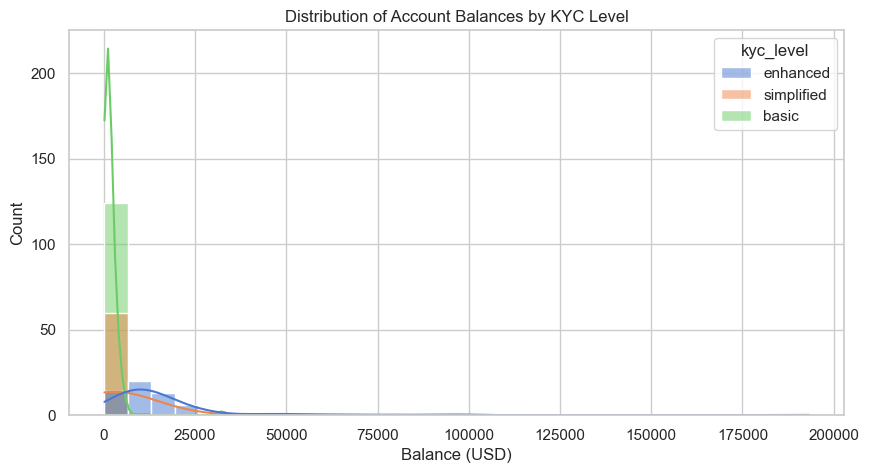

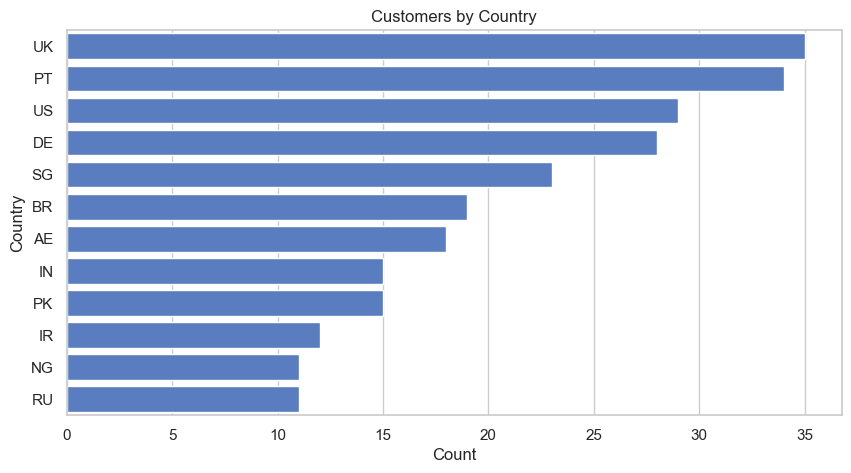

In [7]:
print("Customer Data Overview:")

# Balance distribution by KYC level
sns.histplot(data=customers, x="balance_usd", hue="kyc_level", kde=True, bins=30)
plt.title("Distribution of Account Balances by KYC Level")
plt.xlabel("Balance (USD)")
plt.ylabel("Count")
plt.show()

# Country distribution
sns.countplot(data=customers, y="country", order=customers["country"].value_counts().index)
plt.title("Customers by Country")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

Transaction Data Overview:


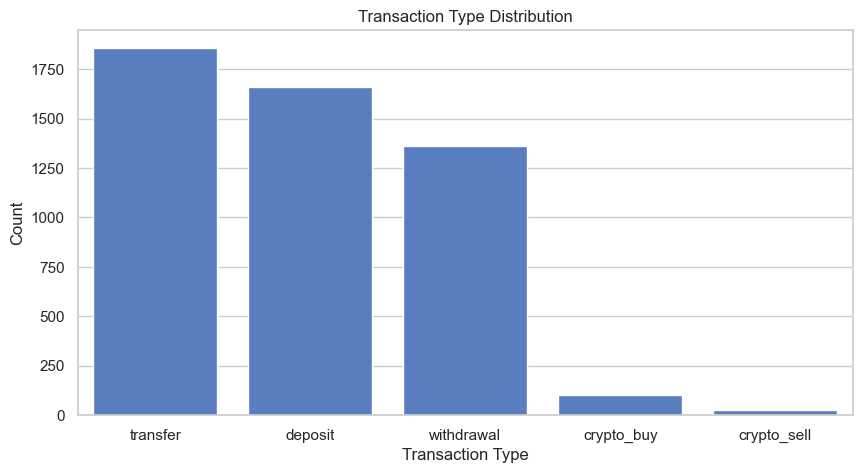

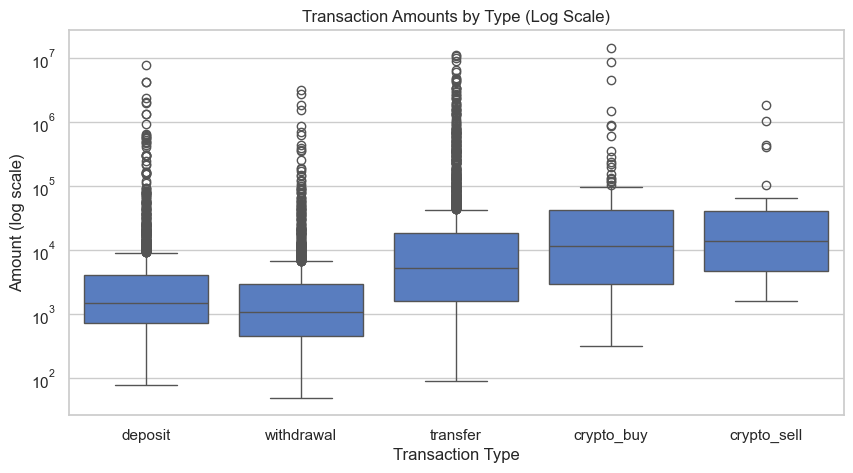

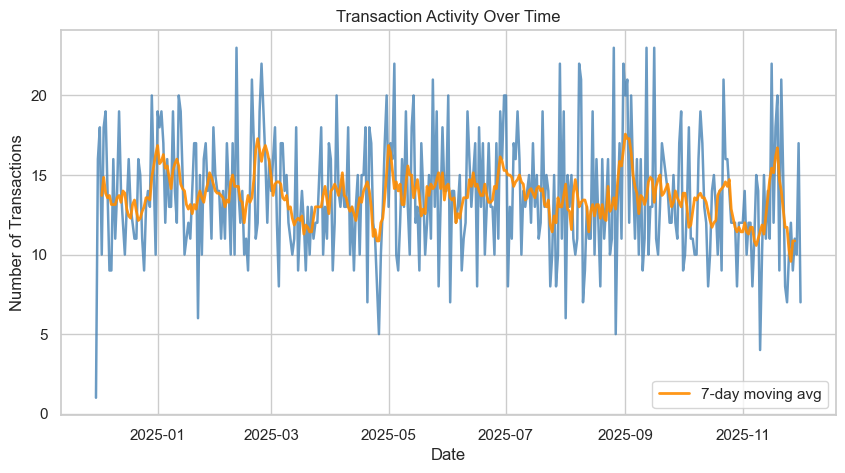

In [8]:
print("Transaction Data Overview:")

# Transaction type frequency
sns.countplot(data=trx, x="trx_type", order=trx["trx_type"].value_counts().index)
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

# Transaction amount distribution
sns.boxplot(data=trx, x="trx_type", y="amount")
plt.yscale("log")
plt.title("Transaction Amounts by Type (Log Scale)")
plt.xlabel("Transaction Type")
plt.ylabel("Amount (log scale)")
plt.show()

# Time series of transactions
trx["date"] = trx["timestamp"].dt.date
trx_per_day = trx.groupby("date").size()
plt.plot(trx_per_day.index, trx_per_day.values, color="steelblue", linewidth=1.8, alpha=0.8)
plt.plot(trx_per_day.index, trx_per_day.rolling(window=7, center=True).mean(),
         color="darkorange", linewidth=2, alpha=0.9, label="7-day moving avg")
plt.title("Transaction Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.legend()
plt.show()

Crypto Wallet Data Overview:


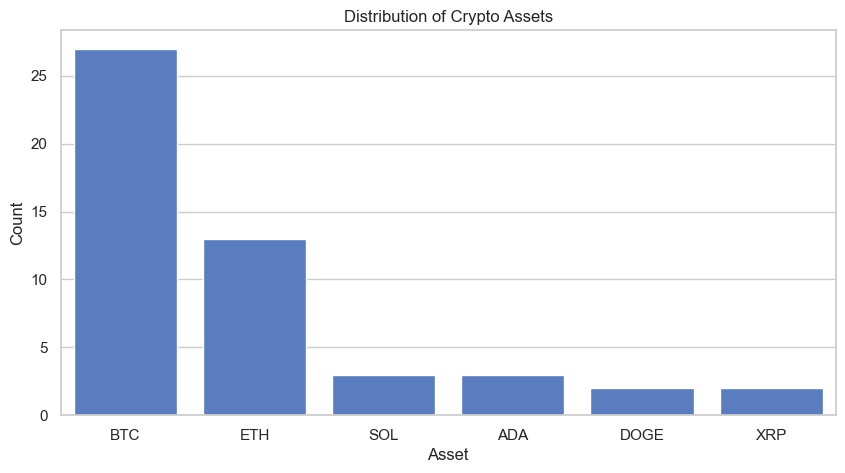

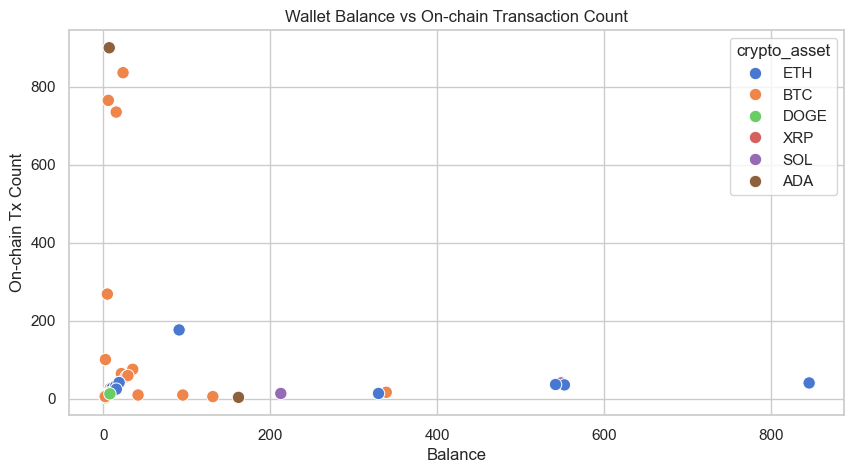

In [9]:
print("Crypto Wallet Data Overview:")

# Crypto asset distribution
sns.countplot(data=crypto, x="crypto_asset", order=crypto["crypto_asset"].value_counts().index)
plt.title("Distribution of Crypto Assets")
plt.xlabel("Asset")
plt.ylabel("Count")
plt.show()

# Wallet balance vs on-chain activity correlation
sns.scatterplot(data=crypto, x="balance", y="on_chain_tx_count", hue="crypto_asset", s=80)
plt.title("Wallet Balance vs On-chain Transaction Count")
plt.xlabel("Balance")
plt.ylabel("On-chain Tx Count")
plt.show()

## Enforcing Native Python Data Types in Schemas

To ensure compatibility with downstream systems and model interfaces, we normalize schema definitions into strict native Python datatypes.  
This step prevents type drift and simplifies automated validation.

In [10]:
# Force native Python strings
trx['currency'] = trx['currency'].map(str)
trx['trx_type'] = trx['trx_type'].map(str)
trx['customer_id'] = trx['customer_id'].map(str)
trx['receiver_id'] = trx['receiver_id'].map(lambda x: str(x) if x is not None else None)
trx['description'] = trx['description'].map(str)
trx['trx_id'] = trx['trx_id'].map(str)

# Force native Python floats
trx['amount'] = trx['amount'].astype(float)
trx['amount_z'] = trx['amount_z'].astype(float)

# Force native Python ints
int_cols = [
    'c_txn_7d', 'kw_flag', 'multi_country_flag', 'structuring_flag',
    'many_trx_types_flag', 'crypto_activity_flag', 'velocity_spike_flag'
]
for col in int_cols:
    trx[col] = trx[col].astype(int)

# Keep only the schema columns
columns_to_keep = [
    'trx_id', 'timestamp', 'customer_id', 'receiver_id', 'currency', 'amount',
    'trx_type', 'description', 'amount_z', 'c_txn_7d', 'kw_flag',
    'multi_country_flag', 'structuring_flag', 'many_trx_types_flag',
    'crypto_activity_flag', 'velocity_spike_flag'
]
trx = trx[columns_to_keep]


## Define data schemas

Definition of the data schemas to be used during the agent-workflow.

Schemas act as a contract for the structure, types, and constraints of the data, ensuring consistency across all steps from dataset generation and enrichment to validation, transformation, and agent reasoning.

By establishing well-structured schemas early, we reduce ambiguity, prevent type drift, and enable the agent to make reliable assumptions about the data it processes.

In [11]:
class Customer(BaseModel):
    # Original customer fields
    customer_id: constr(pattern=r"^CUST-\d+$") = Field(..., description="Unique customer ID")
    name: str = Field(..., description="Customer full name")
    dob: date = Field(..., description="Date of birth")
    country: str = Field(..., description="Country of residence")
    kyc_level: Literal["simplified","basic","enhanced"] = Field(..., description="KYC verification level")
    account_open_date: date = Field(..., description="Date when the account was opened")
    balance_usd: confloat(ge=0) = Field(..., description="Current account balance in USD")
    
    # Transaction history fields
    total_transactions: int = Field(0, description="Total number of transactions")
    total_volume_usd: confloat(ge=0) = Field(0.0, description="Total transaction volume in USD")
    avg_transaction_amount: confloat(ge=0) = Field(0.0, description="Average transaction amount")
    max_transaction_amount: confloat(ge=0) = Field(0.0, description="Maximum transaction amount")
    unique_transaction_types: int = Field(0, description="Number of unique transaction types used")
    unique_currencies: int = Field(0, description="Number of unique currencies used")
    customer_lifetime_days: int = Field(0, description="Days since first transaction")
    avg_transactions_per_day: confloat(ge=0) = Field(0.0, description="Average transactions per day")

# Crypto wallet schema
class Crypto(BaseModel):
    wallet_id: constr(pattern=r"^WALLET-\d+$") = Field(..., description="Unique wallet ID")
    customer_id: constr(pattern=r"^CUST-\d+$") = Field(..., description="Associated customer ID")
    crypto_asset: Literal["BTC","ETH","USDT","SOL","BNB","DOGE","XRP","ADA"] = Field(..., description="Crypto asset type")
    wallet_address: str = Field(..., description="Wallet address hash")
    balance: confloat(ge=0) = Field(..., description="Wallet balance")
    on_chain_tx_count: int = Field(..., description="Number of on-chain transactions")

# Transaction schema
class Transaction(BaseModel):
    trx_id: constr(pattern=r"^TX-\d+$") = Field(..., description="Unique transaction ID")
    timestamp: datetime = Field(..., description="Timestamp of the transaction")
    customer_id: constr(pattern=r"^CUST-\d+$") = Field(..., description="Sender customer ID")
    receiver_id: Optional[constr(pattern=r"^CUST-\d+$")] = Field(None, description="Receiver customer ID (only for transfers)")
    currency: Literal["USD","EUR","GBP","BTC","ETH","USDT","XRP","SOL","ADA","DOGE"] = Field(..., description="Transaction currency")
    amount: confloat(gt=0) = Field(..., description="Transaction amount")
    trx_type: Literal["deposit","withdrawal","transfer","crypto_buy","crypto_sell"] = Field(..., description="Transaction type")
    description: str = Field(..., description="Transaction description/narrative")
    amount_z: float = Field(..., description="Z-score of the transaction amount relative to all transactions")
    c_txn_7d: int = Field(..., description="Number of transactions by the customer in the past 7 days")
    kw_flag: int = Field(..., description="Keyword flag (1 if description contains red-flag keywords, else 0)")
    multi_country_flag: int = Field(..., description="Flag if the customer sent transfers to multiple countries")
    structuring_flag: int = Field(..., description="Structuring flag (1 if many small transactions within a month, else 0)")
    many_trx_types_flag: int = Field(..., description="Flag if the customer has transactions of many different types")
    crypto_activity_flag: int = Field(..., description="Flag if the customer has crypto buy/sell activity")
    velocity_spike_flag: int = Field(..., description="Flag if the customer's transaction volume suddenly spiked")

# Risk label schema
class RiskLabel(BaseModel):
    score: confloat(ge=0.0, le=100.0) = Field(0.0, description="Risk score (0-100)")
    reason: str = Field(..., description="Reason for risk level")

# Report document schema
class ReportDoc(BaseModel):
    title: str = Field(..., description="Report title")
    summary: str = Field(..., description="Short summary of transaction and findings")
    main_risks: List[str] = Field(..., description="List of key risk factors")
    counterparty_context: str = Field(..., description="Context of customer/counterparty")
    timeline: List[str] = Field(..., description="Chronological list of events")
    recommendation: str = Field(..., description="Recommended next action")

    class Config:
        extra = "forbid"

# Case state schema
class AMLState(BaseModel):
    # Data
    txn: Optional[Transaction] = None
    customer: Optional[Customer] = None
    crypto: Optional[Crypto] = None

    # Risk agents results
    behavior_risk: Optional[RiskLabel] = None
    geo_risk: Optional[RiskLabel] = None
    crypto_risk: Optional[RiskLabel] = None

    # Aggregate results
    final_risk_score: Optional[int] = None
    risk_level: str = None

    # Routing
    next_action: Optional[str] = None
    processing_complete: bool = None

    # Reporting - FIX THIS LINE
    requires_doc: Optional[bool] = None
    typology: Optional[str] = None
    typology_rationale: Optional[str] = None
    report: Optional[ReportDoc] = None

    # Metadata
    logs: List[str]



In [12]:
def validate_dataframe(df: pd.DataFrame, model):
    records = df.to_dict(orient="records")
    valid_objects = []
    errors = []

    for i, record in enumerate(records):
        try:
            valid_objects.append(model(**record))
        except ValidationError as e:
            errors.append((i, record, e))

    return valid_objects, errors


# Validate dfs using schemas
validated_customers, customer_errors = validate_dataframe(customers, Customer)
validated_crypto, crypto_errors = validate_dataframe(crypto, Crypto)
validated_trx, trx_errors = validate_dataframe(trx, Transaction)

print(f"Customer errors: {len(customer_errors)}")
print(f"Crypto wallet errors: {len(crypto_errors)}")
print(f"Transaction errors: {len(trx_errors)}")


Customer errors: 0
Crypto wallet errors: 0
Transaction errors: 0


## Score Rules

Scoring rules are defined to guide the agent towards better decision-making.

In [13]:
def behavior_score_rules(row: pd.Series | None = None) -> Dict[str, Any]:
    """
    Calculate behavior risk score using rule-based logic - MUCH MORE AGGRESSIVE VERSION
    """
    points, reasons = 0, []
    amt = float(row.get("amount", 0))

    # Amount-based scoring
    if amt >= 100000:
        points += 50; reasons.append("Extremely high amount >= 100k")
    elif amt >= 50000:
        points += 40; reasons.append("Very high amount >= 50k")
    elif amt >= 25000:
        points += 30; reasons.append("High amount >= 25k")
    elif amt >= 10000:
        points += 20; reasons.append("Elevated amount >= 10k")
    elif amt >= 5000:
        points += 10; reasons.append("Notable amount >= 5k")
    elif amt >= 2000:
        points += 5; reasons.append("Moderate amount >= 2k")

    # Velocity scoring
    velocity = int(row.get("c_txn_7d", 0))
    if velocity >= 10:
        points += 50; reasons.append("Extreme velocity (>=10 txns in 7d)")
    elif velocity >= 7:
        points += 40; reasons.append("Very high velocity (>=7 txns)")
    elif velocity >= 5:
        points += 30; reasons.append("High velocity (>=5 txns)")
    elif velocity >= 3:
        points += 20; reasons.append("Elevated velocity (>=3 txns)")
    elif velocity >= 2:
        points += 10; reasons.append("Moderate velocity (>=2 txns)")

    # Flag penalties
    if int(row.get("kw_flag", 0)) == 1:
        points += 25; reasons.append("SUSPICIOUS KEYWORDS DETECTED")

    if int(row.get("multi_country_flag", 0)) == 1:
        points += 10; reasons.append("MULTI-COUNTRY TRANSFERS")
    
    if int(row.get("structuring_flag", 0)) == 1:
        points += 40; reasons.append("STRUCTURING PATTERN DETECTED")
    
    if int(row.get("many_trx_types_flag", 0)) == 1:
        points += 10; reasons.append("DIVERSE TRANSACTION TYPES")

    if int(row.get("crypto_activity_flag", 0)) == 1:
        points += 15; reasons.append("CRYPTOCURRENCY INVOLVEMENT")

    if int(row.get("velocity_spike_flag", 0)) == 1:
        points += 30; reasons.append("VELOCITY SPIKE DETECTED")

    # Enhanced Z-score penalties
    z_score = abs(float(row.get("amount_z", 0)))
    if z_score >= 3.0:
        points += 40; reasons.append(f"Statistical anomaly (z-score: {z_score:.1f})")
    elif z_score >= 2.0:
        points += 30; reasons.append(f"Statistical outlier (z-score: {z_score:.1f})")
    elif z_score >= 1.5:
        points += 20; reasons.append(f"Statistical deviation (z-score: {z_score:.1f})")

    # Enhanced transaction type rules
    trx_type = row.get("trx_type", "")
    if trx_type in ["crypto_buy", "crypto_sell"]:
        points += 20; reasons.append("Crypto transaction inherent risk")
        if amt >= 1000:
            points += 10; reasons.append("Large crypto transaction")
    elif trx_type == "transfer" and amt >= 5000:
        points += 10; reasons.append("Large transfer amount")

    # Multiple flag multiplier
    flag_count = sum([
        int(row.get("kw_flag", 0)),
        int(row.get("multi_country_flag", 0)),
        int(row.get("structuring_flag", 0)),
        int(row.get("many_trx_types_flag", 0)),
        int(row.get("crypto_activity_flag", 0)),
        int(row.get("velocity_spike_flag", 0))
    ])
    
    if flag_count >= 3:
        points += 30; reasons.append(f"Multiple risk flags detected ({flag_count})")
    elif flag_count >= 2:
        points += 10; reasons.append(f"Multiple risk indicators ({flag_count})")

    points = min(points, 100)
    
    if points >= 60:
        base = "Very High"
    elif points >= 40:
        base = "High"
    elif points >= 25:
        base = "Medium"
    elif points >= 15:
        base = "Low-Medium"
    else:
        base = "Low"

    return {
        "points": points, 
        "score": points,
        "base_level": base, 
        "reasons": reasons
    }

In [14]:
def geo_score_rules(row: pd.Series, customers: pd.DataFrame) -> Dict[str, Any]:
    """
    Geographical risk scoring based on sender and receiver countries.
    """
    high_risk_countries = {"RU", "IR", "PK", "NG", "YE", "SY"}
    offshore_centers = {"KY", "VG", "PA", "BS", "MU", "BM"}
    sanctioned = {"RU", "IR", "SY", "KP"}
    
    # Extract sender and receiver country
    sender_country = str(row.get("country") or row.get("customer_country", "")).upper()
    receiver_id = row.get("receiver_id")
    receiver_country = ""
    # Lookup receiver country if applicable
    if receiver_id and receiver_id in set(customers["customer_id"]):
        receiver_country = str(
            customers.loc[customers["customer_id"] == receiver_id, "country"].values[0]
        ).upper()

    cross_border = bool(receiver_country and receiver_country != sender_country)

    hints = {
        "customer_country": sender_country,
        "receiver_country": receiver_country or None,
        "cross_border": cross_border,
        "sender_high_risk": sender_country in high_risk_countries,
        "receiver_high_risk": receiver_country in high_risk_countries,
        "sender_offshore": sender_country in offshore_centers,
        "receiver_offshore": receiver_country in offshore_centers,
        "sender_sanctioned": sender_country in sanctioned,
        "receiver_sanctioned": receiver_country in sanctioned,
    }

    reasons = []
    score = 0

    if hints["cross_border"]:
        score += 2; reasons.append("Cross-border transaction")
    if hints["receiver_high_risk"] or hints["sender_high_risk"]:
        score += 3; reasons.append("Involves high-risk jurisdiction")
    if hints["receiver_offshore"] or hints["sender_offshore"]:
        score += 2; reasons.append("Offshore jurisdiction involvement")
    if hints["receiver_sanctioned"] or hints["sender_sanctioned"]:
        score += 5; reasons.append("Sanctioned country detected")

    base_level = (
        "Very High" if score >= 6 else
        "High" if score >= 4 else
        "Medium" if score >= 2 else
        "Low"
    )

    hints.update({
        "points": score,
        "base_level": base_level,
        "reasons": reasons
    })

    return hints


## Ingestion Helper

The ingestion helper centralizes the logic for loading, validating, transforming, and preparing datasets for use by downstream agents.


In [15]:
def make_txn_event(row: pd.Series) -> Transaction:
    return Transaction(
        trx_id=str(row.get("trx_id", "")),
        timestamp=pd.to_datetime(row.get("timestamp")) if pd.notna(row.get("timestamp")) else datetime.now(),
        customer_id=str(row.get("customer_id", "")),
        receiver_id=str(row["receiver_id"]) if pd.notna(row.get("receiver_id")) else None,
        currency=str(row.get("currency", "")),
        amount=float(row.get("amount", 0.0)),
        trx_type=str(row.get("trx_type", "")),
        description=str(row.get("description", "")),
        amount_z=float(row.get("amount_z", 0.0)),
        c_txn_7d=int(row.get("c_txn_7d", 0)),
        kw_flag=int(row.get("kw_flag", 0)),
        multi_country_flag=int(row.get("multi_country_flag", 0)),  # Changed from bool to int
        structuring_flag=int(row.get("structuring_flag", 0)),
        many_trx_types_flag=int(row.get("many_trx_types_flag", 0)),
        crypto_activity_flag=int(row.get("crypto_activity_flag", 0)),
        velocity_spike_flag=int(row.get("velocity_spike_flag", 0))
    )


## Agents
The workflow defines several specialized agents, each responsible for analyzing the dataset from a different perspective.

### Behaviour assesment agent
Evaluates behavioral patterns, risk profiles, and trends within participant‑level data. This agent may use scoring rules, statistical signals, or LLM‑derived insights.

In [16]:
behavior_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an expert AML analyst evaluating transactional behavior patterns. Your role is to assess money laundering risk based on transaction characteristics, customer behavior, and risk indicators."),
    ("human", """Analyze this transaction for behavioral money laundering risk indicators:

**Risk Factors to Consider:**
- Transaction velocity: High frequency of transactions may indicate layering or structuring
- Suspicious keywords: Terms like "urgent", "gift", "cash", "crypto", "split" often appear in suspicious narratives
- Structuring patterns: Multiple small transactions designed to avoid reporting thresholds
- Transaction diversity: Unusual variety in transaction types may indicate sophisticated laundering
- Amount patterns: Statistical outliers or amounts just below reporting thresholds
- Timing patterns: Off-hours or clustered transaction timing

**Assessment Guidelines:**
- Consider the cumulative effect of multiple risk factors
- Higher transaction amounts combined with risk flags warrant increased concern
- Velocity spikes combined with suspicious narratives are particularly concerning
- Evaluate patterns in context of legitimate business activity

**Scoring Framework:**
- 0-20: Minimal risk - Normal transaction patterns, no concerning indicators
- 21-40: Low-Medium risk - Minor indicators or slightly elevated patterns
- 41-65: Medium-High risk - Multiple concerning indicators or significant patterns
- 66-85: High risk - Strong evidence of suspicious behavior patterns
- 86-100: Extreme risk - Clear indicators of likely money laundering activity

Provide your assessment as JSON: {{"score": integer, "reason": "detailed explanation of risk factors and reasoning (<120 words)"}}.

**Transaction Data:** {txn_json}
**Customer Profile:** {customer_json}
**Behavioral Analysis:** {behavior_hints}

Provide only the JSON response:""")
])

def behavior_risk_agent(txn: Transaction, customer: Customer, behavior_hints: Dict[str, Any]) -> RiskLabel:
    """
    Evaluate behavioral risk using LLM based on transaction and customer data plus behavior hints.
    """
    chain = behavior_prompt | llm.with_structured_output(RiskLabel)
    return chain.invoke({
        "txn_json": json.dumps(txn.model_dump(), ensure_ascii=False),
        "customer_json": json.dumps(customer.model_dump(), ensure_ascii=False),
        "behavior_hints": json.dumps(behavior_hints, ensure_ascii=False)
    })

### Geographic analysis agent
Analyzes geographic variables, such as environmental conditions, regional metrics, or mobility patterns, to produce insights relevant to location‑dependent studies.

In [17]:
geo_risk_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an expert AML analyst specializing in geographic risk assessment. You evaluate money laundering risk based on jurisdictional factors, cross-border patterns, and geopolitical considerations."),
    ("human", """Assess the geographic money laundering risk for this transaction:

**Geographic Risk Factors:**
- Cross-border transactions: International transfers carry inherent ML risk
- High-risk jurisdictions: Countries with weak AML controls or high corruption
- Offshore financial centers: Jurisdictions known for banking secrecy
- Sanctioned countries: Nations under international sanctions
- Tax havens: Jurisdictions with favorable tax treatment attracting illicit funds
- Political instability: Regions with ongoing conflicts or weak governance

**Key Considerations:**
- Domestic transactions in low-risk countries typically pose minimal geographic risk
- Cross-border flows to/from high-risk countries warrant elevated scrutiny
- Multiple jurisdictions in transaction chains increase complexity and risk
- Economic rationale for cross-border activity should be apparent
- Sanctions compliance is mandatory - any sanctioned country involvement is critical

**Risk Assessment Scale:**
- 0-15: Minimal risk - Domestic transactions in stable, well-regulated jurisdictions
- 16-35: Low-Medium risk - Cross-border to well-regulated countries with clear purpose
- 36-60: Medium-High risk - Involvement of higher-risk jurisdictions or complex routing
- 61-80: High risk - Multiple high-risk jurisdictions or concerning geographic patterns
- 81-100: Extreme risk - Sanctioned countries or clear geographic laundering indicators

Return JSON: {{"score": integer, "reason": "detailed geographic risk analysis (<120 words)"}}

**Transaction:** {txn_json}
**Customer:** {customer_json}
**Geographic Context:** {geo_hints}

JSON response only:""")
])

def geo_risk_agent(txn: Transaction, customer: Customer, geo_hints: Dict[str, Any]) -> RiskLabel:
    """
    Evaluates geographic risk exposure of a transaction using customer data and
    contextual geographic hints (e.g., sanctioned countries, offshore jurisdictions).
    """
    chain = geo_risk_prompt | llm.with_structured_output(RiskLabel)
    return chain.invoke({
        "txn_json": json.dumps(txn.model_dump(), ensure_ascii=False),
        "customer_json": json.dumps(customer.model_dump(), ensure_ascii=False),
        "geo_hints": json.dumps(geo_hints, ensure_ascii=False)
    })

### Crypto analysis agent
Assesses cryptocurrency user behaviors, or transaction‑level metadata looking for suspicious crypto wallets and behaviors. 

In [18]:
crypto_risk_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an expert AML analyst specializing in cryptocurrency and digital asset money laundering risk. You assess the ML risk associated with crypto transactions and digital asset activity."),
    ("human", """Evaluate cryptocurrency-related money laundering risk for this transaction:

**Crypto Risk Factors:**
- Digital asset involvement: Cryptocurrencies can facilitate anonymous transfers
- Transaction amounts: Large crypto transactions warrant additional scrutiny
- Wallet activity: High on-chain transaction volumes may indicate mixing/tumbling
- Asset types: Some cryptocurrencies offer enhanced privacy features
- Exchange patterns: Rapid conversion between crypto and fiat can indicate laundering
- On-chain behavior: Complex transaction chains may obscure fund origins

**Assessment Considerations:**
- Not all crypto activity is suspicious - legitimate use is common
- Consider transaction purpose and customer profile
- Large amounts in crypto deserve elevated attention due to anonymity potential
- Multiple crypto assets or complex patterns increase risk
- Privacy-focused cryptocurrencies carry inherent ML risk
- Timing and frequency of crypto activity matters

**Risk Evaluation:**
- 0-10: No crypto involvement - Traditional fiat transaction only
- 11-25: Minimal crypto risk - Small amounts, clear legitimate purpose
- 26-45: Low-Medium risk - Moderate crypto activity with some concerning aspects
- 46-70: Medium-High risk - Significant crypto involvement or suspicious patterns
- 71-90: High risk - Large amounts, complex patterns, or multiple red flags
- 91-100: Extreme risk - Clear indicators of crypto-facilitated money laundering

Respond with JSON: {{"score": integer, "reason": "detailed cryptocurrency risk assessment (<120 words)"}}

**Transaction:** {txn_json}
**Customer:** {customer_json}
**Crypto Data:** {crypto_json}

JSON only:""")
])

def crypto_risk_agent(txn: Transaction, customer: Customer, crypto: Crypto) -> RiskLabel:
    """
    Evaluate cryptocurrency-related risk using LLM based on transaction, customer, and crypto wallet data.
    """
    chain = crypto_risk_prompt | llm.with_structured_output(RiskLabel)
    return chain.invoke({
        "txn_json": json.dumps(txn.model_dump(), ensure_ascii=False),
        "customer_json": json.dumps(customer.model_dump(), ensure_ascii=False),
        "crypto_json": json.dumps(crypto.model_dump(), ensure_ascii=False)
    })

## Workflow functions
Workflow functions orchestrate the execution pipeline by chaining together ingestion steps, agent analyses, validation routines, and output formatting.

In [19]:
def clamp_score(score: Union[int, float], min_val: int = 0, max_val: int = 100)->int:
    return max(min_val, min(max_val, int(score)))

In [20]:
def calculate_final_score(risk_components: List[Dict[str, Any]], transaction_amount: float = 0) -> Dict[str, Any]:
    if not risk_components:
        return {"total_score": 0, "weighted_components": [], "aggregation_method": "no_components"}
   
    # Dynamic weight adjustment based on transaction amount
    base_weights = {
        'Geographic': 0.25,
        'Behavioral': 0.50,
        'Crypto': 0.25
    }
   
    # High-value transactions increase document and geographic weights
    if transaction_amount >= 50000:
        base_weights['Geographic'] = 0.45
        base_weights['Behavioral'] = 0.40
        base_weights['Crypto'] = 0.15
   
    # Apply weights to components
    weighted_components = []
    total_weighted_score = 0
    total_weight = 0
   
    for comp in risk_components:
        comp_type = comp['type']
        weight = base_weights.get(comp_type, 0.25)
        weighted_score = comp['score'] * weight
       
        weighted_components.append({
            'type': comp_type,
            'score': comp['score'],
            'weight': weight,
            'weighted_score': weighted_score
        })
       
        total_weighted_score += weighted_score
        total_weight += weight
   
    # Calculate final score
    final_score = clamp_score(total_weighted_score / total_weight if total_weight > 0 else 0)
   
    return {
        "total_score": final_score,
        "weighted_components": weighted_components,
        "aggregation_method": "dynamic_weighted",
        "total_weight": total_weight
    }

In [21]:
def calculate_risk_level(total_score: int) -> str:
    if total_score >= 70:
        return "EXTREME"
    elif total_score >= 45:
        return "HIGH"
    elif total_score >= 25:
        return "MEDIUM" 
    else:
        return "LOW"

In [22]:
def should_generate_doc(risk_level: str, final_score: int) -> bool:
    return risk_level in ["EXTREME", "HIGH"] or final_score >= 50

In [23]:
def classify_threat_typology(state: Dict[str, Any]) -> Dict[str, str]:
    # Analyze risk patterns to determine typology
    geo_score = state.get("geographic_risk", {}).get("score", 0) if state.get("geographic_risk") else 0
    behavioral_score = state.get("behavioral_risk", {}).get("score", 0) if state.get("behavioral_risk") else 0
    crypto_score = state.get("crypto_risk", {}).get("score", 0) if state.get("crypto_risk") else 0
   
    transaction = state.get("transaction", {})
    amount = transaction.get("amount", 0)
    frequency = transaction.get("frequency", 1)
   
    # Typology classification logic
    if crypto_score >= 60:
        return {
            "typology": "Digital Asset Laundering",
            "rationale": f"High crypto risk score ({crypto_score}) indicates potential cryptocurrency-based money laundering"
        }
    elif behavioral_score >= 60 and frequency >= 5:
        return {
            "typology": "Structuring/Smurfing",
            "rationale": f"High behavioral score ({behavioral_score}) with frequent transactions ({frequency}) indicates structuring"
        }
    elif geo_score >= 60:
        return {
            "typology": "Cross-Border Layering",
            "rationale": f"High geographic risk score ({geo_score}) suggests suspicious cross-border activity"
        }
    elif amount >= 50000:
        return {
            "typology": "High-Value Transaction Monitoring",
            "rationale": f"Large transaction amount (${amount:,.2f}) requires enhanced monitoring"
        }
    else:
        return {
            "typology": "General Suspicious Activity",
            "rationale": "Multiple risk indicators present but no specific typology pattern identified"
        }


In [24]:
def determine_next_action(state: Dict[str, Any]) -> str:
    risk_level = state.get("risk_level", "LOW")
    total_score = state.get("total_risk_score", 0)
    requires_sar = state.get("requires_sar", False)
   
    # Critical path routing
    if total_score >= 90:
        return "immediate_investigation"
    elif total_score >= 80:
        return "priority_doc_review"
    elif requires_sar:
        return "generate_doc_report"
    elif risk_level == "HIGH":
        return "enhanced_monitoring"
    elif risk_level == "MEDIUM":
        return "standard_monitoring"
    else:
        return "standard_processing"

In [25]:
def should_route_to_doc_generation(state: Dict[str, Any]) -> bool:
    next_action = state.get("next_action")
    return next_action in ["immediate_investigation", "priority_doc_review", "generate_report"]

## Graph design
The final section builds and visualizes the computational graph that represents the workflow. This graph:

- Defines dependencies between ingestion, agents, scoring rules, and output steps

- Helps ensure reproducibility

- Supports debugging and optimization

- Provides a high‑level overview of the entire pipeline

Graph‑based design assists in both documentation and orchestration of complex workflows.

In [ ]:
def initialize_state(trx: Dict[str, Any],
                     customer: Dict[str, Any],
                     crypto: Optional[Dict[str, Any]] = None) -> AMLState:
    return AMLState(
        txn=Transaction(**trx),
        customer=Customer(**customer),
        crypto=Crypto(**crypto) if crypto else None,
        behavior_risk=None,
        geo_risk=None,
        crypto_risk=None,
        final_risk_score=None,
        risk_level=None,
        next_action=None,
        processing_complete=False,
        requires_doc=None,
        typology=None,
        typology_rationale=None,
        report=None,
        logs=[f"State initialized at {datetime.now().isoformat()}"]
    )

def behavior_risk_node(state: Dict[str, Any]) -> Dict[str, Any]:
    try:
        txn_data = state["txn"]
        customer_data = state["customer"]
        logs = state.get("logs", [])
        
        txn = Transaction(**txn_data) if isinstance(txn_data, dict) else txn_data
        customer = Customer(**customer_data) if isinstance(customer_data, dict) else customer_data
        
        behavior_hints = behavior_score_rules(pd.Series(txn.model_dump()))
        result = behavior_risk_agent(txn, customer, behavior_hints)
        
        state["behavior_risk"] = {
            "score": clamp_score(result.score),
            "reason": result.reason
        }
        state["logs"] = logs + [f"Behavior risk: {clamp_score(result.score)}/100"]
        
    except Exception as e:
        logs = state.get("logs", [])
        state["logs"] = logs + [f"Behavior analysis failed: {str(e)}"]
        state["behavior_risk"] = {"score": 50.0, "reason": "Analysis failed - default medium risk"}

    print("[Test] Behavior Risk Node State:", state["behavior_risk"])
    
    return state

def geo_risk_node(state: Dict[str, Any]) -> Dict[str, Any]:
    try:
        txn_data = state["txn"]
        customer_data = state["customer"]
        logs = state.get("logs", [])
        
        txn = Transaction(**txn_data) if isinstance(txn_data, dict) else txn_data
        customer = Customer(**customer_data) if isinstance(customer_data, dict) else customer_data
        
        # Create a row-like object for geo_score_rules
        txn_dict = txn.model_dump()
        txn_dict["country"] = customer.country
        geo_hints = geo_score_rules(pd.Series(txn_dict), customers)
        
        result = geo_risk_agent(txn, customer, geo_hints)
        
        state["geo_risk"] = {
            "score": clamp_score(result.score),
            "reason": result.reason
        }
        state["logs"] = logs + [f"Geographic risk: {clamp_score(result.score)}/100"]
        
    except Exception as e:
        logs = state.get("logs", [])
        state["logs"] = logs + [f"Geographic analysis failed: {str(e)}"]
        state["geo_risk"] = {"score": 30.0, "reason": "Analysis failed - default low-medium risk"}

    print("[Test] Geo Risk Node State:", state["geo_risk"])
    
    return state

def crypto_risk_node(state: Dict[str, Any]) -> Dict[str, Any]:
    try:
        txn_data = state["txn"]
        customer_data = state["customer"]
        crypto_data = state.get("crypto")
        logs = state.get("logs", [])
        
        txn = Transaction(**txn_data) if isinstance(txn_data, dict) else txn_data
        customer = Customer(**customer_data) if isinstance(customer_data, dict) else customer_data
        crypto_obj = Crypto(**crypto_data) if crypto_data and isinstance(crypto_data, dict) else crypto_data
        
        if crypto_obj:
            result = crypto_risk_agent(txn, customer, crypto_obj)
            state["crypto_risk"] = {
                "score": clamp_score(result.score),
                "reason": result.reason
            }
        else:
            state["crypto_risk"] = {"score": 0.0, "reason": "No crypto activity detected"}
        
        state["logs"] = logs + [f"Crypto risk: {state['crypto_risk']['score']}/100"]
        
    except Exception as e:
        logs = state.get("logs", [])
        state["logs"] = logs + [f"Crypto analysis failed: {str(e)}"]
        state["crypto_risk"] = {"score": 20.0, "reason": "Analysis failed - default low risk"}

    print("[Test] Crypto Risk Node State:", state["crypto_risk"])
    
    return state

def risk_aggregation_node(state: Dict[str, Any]) -> Dict[str, Any]:
    try:
        risk_components = []
        
        if state.get("behavior_risk"):
            risk_components.append({
                "score": state["behavior_risk"]["score"],
                "type": "Behavioral"
            })
        
        if state.get("geo_risk"):
            risk_components.append({
                "score": state["geo_risk"]["score"],
                "type": "Geographic"
            })

        if state.get("crypto_risk"):
            risk_components.append({
                "score": state["crypto_risk"]["score"],
                "type": "Crypto"
            })
        
        # Get transaction amount
        txn_data = state["txn"]
        transaction_amount = txn_data["amount"] if isinstance(txn_data, dict) else txn_data.amount
        
        risk_aggregation = calculate_final_score(risk_components, transaction_amount)
        final_score = risk_aggregation["total_score"]

        state["final_risk_score"] = final_score
        state["risk_level"] = calculate_risk_level(final_score)
        state["requires_doc"] = should_generate_doc(state["risk_level"], final_score)
        
        # Create a state-like dict for classify_threat_typology
        state_dict = {
            "behavioral_risk": {"score": state.get("behavior_risk", {}).get("score", 0)},
            "geographic_risk": {"score": state.get("geo_risk", {}).get("score", 0)},
            "crypto_risk": {"score": state.get("crypto_risk", {}).get("score", 0)},
            "transaction": {
                "amount": transaction_amount, 
                "frequency": txn_data.get("c_txn_7d", 1) if isinstance(txn_data, dict) else txn_data.c_txn_7d
            }
        }

        threat_typology = classify_threat_typology(state_dict)
        state["typology"] = threat_typology["typology"]
        state["typology_rationale"] = threat_typology["rationale"]

        state["next_action"] = determine_next_action({
            "risk_level": state["risk_level"],
            "total_risk_score": state["final_risk_score"],
            "requires_sar": state["requires_doc"]
        })
        
        logs = state.get("logs", [])
        state["logs"] = logs + [f"Risk aggregation: {final_score}/100 ({state['risk_level']})"]
        
    except Exception as e:
        logs = state.get("logs", [])
        state["logs"] = logs + [f"Risk aggregation failed: {str(e)}"]
        state["final_risk_score"] = 50.0
        state["risk_level"] = "MEDIUM"
        state["requires_doc"] = False
        state["next_action"] = "manual_review"

    print("[Test] Risk Aggregation Node State:", state["final_risk_score"], state["risk_level"])
    print("[Test] Typology:", state["typology"], "-", state["typology_rationale"])
    print("[Test] Next Action:", state["next_action"])

    return state

def decision_engine_node(state: Dict[str, Any]) -> Dict[str, Any]:
    try:
        risk_level = state.get("risk_level")
        total_score = state.get("final_risk_score")
        
        if total_score >= 95:
            state["next_action"] = "immediate_investigation"
        elif total_score >= 85:
            state["next_action"] = "priority_review"
        elif state.get("requires_doc"):
            state["next_action"] = "generate_report"
        elif risk_level in ["MEDIUM", "HIGH"]:
            state["next_action"] = "enhanced_monitoring"
        else:
            state["next_action"] = "standard_processing"
        
        state["processing_complete"] = True
        logs = state.get("logs", [])
        state["logs"] = logs + [f"Decision: {state['next_action']}"]
        
    except Exception as e:
        logs = state.get("logs", [])
        state["logs"] = logs + [f"Decision engine failed: {str(e)}"]
        state["next_action"] = "manual_review"
        state["processing_complete"] = True

    return state

def doc_generation_node(state: Dict[str, Any]) -> Dict[str, Any]:
    try:
        txn_data = state["txn"]
        customer_data = state["customer"]
        
        # Convert to objects if needed
        txn = Transaction(**txn_data) if isinstance(txn_data, dict) else txn_data
        customer = Customer(**customer_data) if isinstance(customer_data, dict) else customer_data

        title = f"AML Risk Assessment Report - {txn.trx_id}"
        summary = (
            f"Transaction of {txn.amount:,.2f} {txn.currency} by {customer.name} "
            f"on {txn.timestamp.strftime('%Y-%m-%d %H:%M:%S')}. "
            f"Risk level: {state.get('risk_level', 'Unknown')} "
            f"(Score: {state.get('final_risk_score', 'N/A')})"
        )

        main_risks = []
        if state.get("geo_risk") and state["geo_risk"]["score"] > 0:
            main_risks.append(f"Geographic risk ({state['geo_risk']['score']}/100): {state['geo_risk']['reason']}")
        if state.get("behavior_risk") and state["behavior_risk"]["score"] > 0:
            main_risks.append(f"Behavioral risk ({state['behavior_risk']['score']}/100): {state['behavior_risk']['reason']}")
        if state.get("crypto_risk") and state["crypto_risk"]["score"] > 0:
            main_risks.append(f"Crypto risk ({state['crypto_risk']['score']}/100): {state['crypto_risk']['reason']}")
        
        if not main_risks:
            main_risks.append("No significant risks detected")

        counterparty_context = (
            f"Customer {customer.name} ({customer.customer_id}) from {customer.country}, "
            f"KYC: {customer.kyc_level}, Balance: ${customer.balance_usd:,.2f}"
        )

        timeline = [
            f"{txn.timestamp.strftime('%Y-%m-%d %H:%M:%S')} - Transaction initiated",
            "Risk analysis completed",
            f"Final decision: {state.get('next_action')}"
        ]

        recommendation = f"Recommended action: {state.get('next_action')}"

        report_dict = {
            "title": title,
            "summary": summary,
            "main_risks": main_risks,
            "counterparty_context": counterparty_context,
            "timeline": timeline,
            "recommendation": recommendation
        }

        state["report"] = report_dict
        logs = state.get("logs", [])
        state["logs"] = logs + ["Report generated successfully"]
        
    except Exception as e:
        logs = state.get("logs", [])
        state["logs"] = logs + [f"Report generation failed: {str(e)}"]

    return state

def approved_node(state: Dict[str, Any]) -> Dict[str, Any]:
    print("Calling authorities...")
    return state

def rejected_node(state: Dict[str, Any]) -> Dict[str, Any]:
    return state

def human_approval_call_authorities_node(state: Dict[str, Any]) -> Dict[str,Any]:
    """
    to fill later...
    """
    try:
        decision = interrupt({
            "question": "Trying to call authorities given the following final risk score. Do you approve? (yes/no)",
            "llm_output": state["final_risk_score"]
        })
        logs = state.get("logs", [])
        if decision == "yes":
            return Command(
                goto="approved_path",
                update={
                        "call_authorities": "yes",
                        "logs": logs + ["Action to call authorities approved"]
                    },
            )
        else:
            return Command(
                goto="rejected_path",
                update={
                        "call_authorities": "no",
                        "logs": logs + ["Action to call authorities denied"]
                    },
                )
    except Exception as e:
        logs = state.get("logs", [])
        return Command(
            goto="rejected_path",
            update={
                    "call_authorities": "no",
                    "logs": logs + ["Human approval "]
                },
            )

In [ ]:
def route_after_decision_doc(state: Dict[str, Any]) -> str:
    if state.get("requires_doc"):
        return "doc_generation"
    if state.get("next_action") in ["immediate_investigation", "priority_review", "generate_report"]:
        return "doc_generation"
    return END


def route_after_decision_hitl(state: Dict[str, Any]) -> str:
    return (
        "hitl_call_authorities"
        if state.get("next_action") == "immediate_investigation"
        else END
    )

def build_dynamic_routing_graph() -> StateGraph:
    workflow = StateGraph(Dict[str, Any])
   
    workflow.add_node("behavioral_analysis", behavior_risk_node)
    workflow.add_node("geographic_analysis", geo_risk_node)
    workflow.add_node("crypto_analysis", crypto_risk_node)
    workflow.add_node("risk_aggregation", risk_aggregation_node)
    workflow.add_node("decision_engine", decision_engine_node)
    workflow.add_node("doc_generation", doc_generation_node)
    workflow.add_node("hitl_call_authorities", human_approval_call_authorities_node)
    workflow.add_node("approved_path", approved_node)
    workflow.add_node("rejected_path", rejected_node)
   
    workflow.set_entry_point("behavioral_analysis")
   
    workflow.add_edge("behavioral_analysis", "geographic_analysis")
    workflow.add_edge("geographic_analysis", "crypto_analysis")
    workflow.add_edge("crypto_analysis", "risk_aggregation")
    workflow.add_edge("risk_aggregation", "decision_engine")
   
    workflow.add_conditional_edges(
        "decision_engine",
        route_after_decision_doc,
        {
            "doc_generation": "doc_generation",
            END: END
        }
    )

    workflow.add_conditional_edges(
        "doc_generation",
        route_after_decision_hitl,
        {
            "hitl_call_authorities": "hitl_call_authorities",
            END: END
        }
    )
    workflow.add_edge("approved_path", END)
    workflow.add_edge("rejected_path", END)
   
    memory = MemorySaver()
    app = workflow.compile(checkpointer=memory)
   
    return app

In [ ]:
app = build_dynamic_routing_graph()

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
    print(Image(app.get_graph(xray=True).draw_mermaid_png()))

except Exception:
    print("Graph visualization not available.")
    pass

Graph visualization not available.


In [29]:
def main(test: bool = True):
    """
    Main function to run the AML transaction monitoring system.
    
    Args:
        test: If True, runs on a small sample. If False, processes full dataset.
    
    Returns:
        tuple: (compiled_app, results_dataframe)
    """
    logger.info("Starting AML Transaction Monitoring System")
    
    # Build the workflow application
    app = build_dynamic_routing_graph()
    
    # Determine batch size based on test mode
    if test:
        batch_size = 10
        sample_transactions = trx.sample(50)
        logger.info(f"Test mode: Processing {len(sample_transactions)} transactions")
    else:
        batch_size = 100
        sample_transactions = trx
        logger.info(f"Full mode: Processing {len(sample_transactions)} transactions")
    
    # Process transactions
    results = []
    errors = []
    
    logger.info(f"Processing transactions in batches of {batch_size}")
    
    for i in range(0, len(sample_transactions), batch_size):
        batch = sample_transactions.iloc[i:i+batch_size]
        batch_num = (i // batch_size) + 1
        total_batches = ((len(sample_transactions) - 1) // batch_size) + 1
        
        logger.info(f"Processing batch {batch_num}/{total_batches} ({len(batch)} transactions)")
        
        for _, (_, row) in enumerate(batch.iterrows()):
            try:
                # Get customer data
                customer_row = customers[customers["customer_id"] == row["customer_id"]]
                if customer_row.empty:
                    logger.warning(f"Customer {row['customer_id']} not found, skipping transaction {row['trx_id']}")
                    continue
                
                customer_data = customer_row.iloc[0]
                
                # Get crypto data if available
                crypto_data = None
                crypto_row = crypto[crypto["customer_id"] == row["customer_id"]]
                if not crypto_row.empty:
                    crypto_data = crypto_row.iloc[0]
                
                # Create transaction and customer objects
                txn = make_txn_event(row)
                customer = Customer(**customer_data.to_dict())
                crypto_obj = Crypto(**crypto_data.to_dict()) if crypto_data is not None else None
                
                # Initialize state as dictionary (matching your StateGraph type)
                initial_state = {
                    "txn": txn.model_dump(),
                    "customer": customer.model_dump(),
                    "crypto": crypto_obj.model_dump() if crypto_obj else None,
                    "logs": [f"Transaction {txn.trx_id} processing started"]
                }
                
                # Process through workflow
                final_state = app.invoke(
                    initial_state,
                    config={"configurable": {"thread_id": f"txn-{txn.trx_id}"}}
                )
                
                # Extract results from dictionary state
                result = {
                    "trx_id": final_state["txn"]["trx_id"],
                    "customer_id": final_state["txn"]["customer_id"],
                    "amount": final_state["txn"]["amount"],
                    "currency": final_state["txn"]["currency"],
                    "trx_type": final_state["txn"]["trx_type"],
                    "timestamp": pd.to_datetime(final_state["txn"]["timestamp"]),
                    "behavior_score": final_state.get("behavior_risk", {}).get("score", 0),
                    "behavior_reason": final_state.get("behavior_risk", {}).get("reason", ""),
                    "geo_score": final_state.get("geo_risk", {}).get("score", 0),
                    "geo_reason": final_state.get("geo_risk", {}).get("reason", ""),
                    "crypto_score": final_state.get("crypto_risk", {}).get("score", 0),
                    "crypto_reason": final_state.get("crypto_risk", {}).get("reason", ""),
                    "final_score": final_state.get("final_risk_score", 0),
                    "risk_level": final_state.get("risk_level", "LOW"),
                    "requires_doc": final_state.get("requires_doc", False),
                    "next_action": final_state.get("next_action", "standard_processing"),
                    "typology": final_state.get("typology", "None"),
                    "processing_complete": final_state.get("processing_complete", False),
                    "has_report": final_state.get("report") is not None
                }
                
                results.append(result)
                
                # Log high-risk cases
                if final_state.get("final_risk_score", 0) >= 60:
                    logger.info(f"High-risk transaction detected: {txn.trx_id} (Score: {final_state.get('final_risk_score')})")
                
            except Exception as e:
                error_msg = f"Error processing transaction {row.get('trx_id', 'UNKNOWN')}: {str(e)}"
                logger.error(error_msg)
                errors.append({
                    "trx_id": row.get("trx_id", "UNKNOWN"),
                    "customer_id": row.get("customer_id", "UNKNOWN"),
                    "error": str(e),
                    "error_type": type(e).__name__
                })
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    # Display summary statistics
    if len(results_df) > 0:
        high_risk_count = len(results_df[results_df["risk_level"].isin(["HIGH", "EXTREME"])])
        medium_risk_count = len(results_df[results_df["risk_level"] == "MEDIUM"])
        requires_doc_count = results_df["requires_doc"].sum()
        
        rprint(f"\n[bold green]Processing Complete![/bold green]")
        rprint(f"Total transactions processed: [cyan]{len(results_df)}[/cyan]")
        rprint(f"High/Extreme risk cases: [red]{high_risk_count}[/red]")
        rprint(f"Medium risk cases: [yellow]{medium_risk_count}[/yellow]")
        rprint(f"Documentation required: [orange3]{requires_doc_count}[/orange3]")
        rprint(f"Processing errors: [red]{len(errors)}[/red]")
        
        if high_risk_count > 0:
            rprint(f"\n[bold red]High Risk Cases Summary:[/bold red]")
            high_risk_cases = results_df[results_df["risk_level"].isin(["HIGH", "EXTREME"])]
            display_cols = ["trx_id", "amount", "final_score", "risk_level", "next_action", "typology"]
            display(high_risk_cases[display_cols].head(10))
        
        # Show risk score distribution
        if len(results_df) > 5:
            rprint(f"\n[bold cyan]Risk Score Distribution:[/bold cyan]")
            score_bins = pd.cut(results_df["final_score"], bins=[0, 20, 40, 60, 80, 100], 
                              labels=["Very Low", "Low", "Medium", "High", "Very High"])
            score_dist = score_bins.value_counts().sort_index()
            for level, count in score_dist.items():
                rprint(f"{level}: {count} transactions")
        
        # Show top typologies
        if results_df["typology"].notna().any():
            rprint(f"\n[bold cyan]Top Risk Typologies:[/bold cyan]")
            typology_counts = results_df["typology"].value_counts().head(5)
            for typology, count in typology_counts.items():
                rprint(f"{typology}: {count} cases")
    
    else:
        rprint("[yellow]No transactions were successfully processed![/yellow]")
    
    # Display errors if any
    if errors:
        rprint(f"\n[bold red]Processing Errors ({len(errors)}):[/bold red]")
        error_df = pd.DataFrame(errors)
        display(error_df.head())
    
    logger.info("AML processing completed successfully")
    
    return app, results_df


if __name__ == "__main__":
    # Toggle between test (True) or full run (False)
    app, results = main(test=True)

2025-11-30 19:09:14,383 [INFO] Starting AML Transaction Monitoring System


2025-11-30 19:09:14,450 [INFO] Test mode: Processing 50 transactions
2025-11-30 19:09:14,452 [INFO] Processing transactions in batches of 10
2025-11-30 19:09:14,455 [INFO] Processing batch 1/5 (10 transactions)


[Test] Behavior Risk Node State: {'score': 50.0, 'reason': 'Analysis failed - default medium risk'}
[Test] Geo Risk Node State: {'score': 30.0, 'reason': 'Analysis failed - default low-medium risk'}
[Test] Crypto Risk Node State: {'score': 0.0, 'reason': 'No crypto activity detected'}
[Test] Risk Aggregation Node State: 32 MEDIUM
[Test] Typology: General Suspicious Activity - Multiple risk indicators present but no specific typology pattern identified
[Test] Next Action: standard_monitoring
[Test] Behavior Risk Node State: {'score': 50.0, 'reason': 'Analysis failed - default medium risk'}
[Test] Geo Risk Node State: {'score': 30.0, 'reason': 'Analysis failed - default low-medium risk'}
[Test] Crypto Risk Node State: {'score': 0.0, 'reason': 'No crypto activity detected'}
[Test] Risk Aggregation Node State: 32 MEDIUM
[Test] Typology: General Suspicious Activity - Multiple risk indicators present but no specific typology pattern identified
[Test] Next Action: standard_monitoring
[Test] B

2025-11-30 19:09:14,950 [INFO] Processing batch 2/5 (10 transactions)


[Test] Behavior Risk Node State: {'score': 50.0, 'reason': 'Analysis failed - default medium risk'}
[Test] Geo Risk Node State: {'score': 30.0, 'reason': 'Analysis failed - default low-medium risk'}
[Test] Crypto Risk Node State: {'score': 0.0, 'reason': 'No crypto activity detected'}
[Test] Risk Aggregation Node State: 32 MEDIUM
[Test] Typology: General Suspicious Activity - Multiple risk indicators present but no specific typology pattern identified
[Test] Next Action: standard_monitoring
[Test] Behavior Risk Node State: {'score': 50.0, 'reason': 'Analysis failed - default medium risk'}
[Test] Geo Risk Node State: {'score': 30.0, 'reason': 'Analysis failed - default low-medium risk'}
[Test] Crypto Risk Node State: {'score': 0.0, 'reason': 'No crypto activity detected'}
[Test] Risk Aggregation Node State: 32 MEDIUM
[Test] Typology: General Suspicious Activity - Multiple risk indicators present but no specific typology pattern identified
[Test] Next Action: standard_monitoring
[Test] B

...

Very High: 0 transactions

Top Risk Typologies:

General Suspicious Activity: 43 cases

High-Value Transaction Monitoring: 7 cases

2025-11-30 19:09:15,997 [INFO] AML processing completed successfully
